# Task 3 - Sound Data Collection and Processing
Formative 2: Multimodal Data Preprocessing

For this part we record 2 audio samples per group member ("Yes, approve" / "Confirm transaction"),
look at them as waveforms + spectrograms, augment each sample at least twice, then pull out
MFCCs, spectral roll-off and energy into `audio_features.csv` for the voiceprint model later.

Reusable logic (loading, augmenting, plotting, feature extraction) sits in `src/data/audio_utils.py`
so this notebook stays focused on the workflow, not implementation details.

In [6]:
import sys, os
sys.path.append(os.path.abspath("../src/data"))

import pandas as pd
from audio_utils import (
    load_audio, save_wav, plot_waveform, plot_spectrogram,
    augment_pitch_shift, augment_time_stretch, augment_add_noise,
    extract_features, SAMPLE_RATE
)

RAW_DIR = "../data/unrefined/audios"
CLEAN_DIR = "../data/cleaned/audios"
FEATURES_CSV = "../data/cleaned/audio_features.csv"

# member -> sample number -> raw file
members = ["teta", "sonia", "morsal", "ngabo"]
samples = [1, 2]

## 1. Load samples and check basic info
Just confirming every file loads fine and checking duration/sample rate before we do anything else.

In [7]:
import os, re, shutil

os.makedirs("/content/data/unrefined/audios", exist_ok=True)

for f in os.listdir("/content"):
    if not f.lower().endswith((".m4a", ".mp4")):
        continue
    match = re.search(r"(morsal|teta|ngabo|sonia)\D*(\d)", f, re.IGNORECASE)
    if match:
        member = match.group(1).lower()
        num = match.group(2)
        new_name = f"{member}_{num}.m4a"
        shutil.move(f"/content/{f}", f"/content/data/unrefined/audios/{new_name}")
        print(f"{f}  ->  {new_name}")
    else:
        print(f"couldn't parse: {f}")

In [8]:
os.makedirs("/content/data/cleaned/audios/waveforms", exist_ok=True)
os.makedirs("/content/data/cleaned/audios/spectrograms", exist_ok=True)
os.makedirs("/content/data/cleaned/audios/augmented", exist_ok=True)

RAW_DIR = "/content/data/unrefined/audios"
CLEAN_DIR = "/content/data/cleaned/audios"
FEATURES_CSV = "/content/data/cleaned/audio_features.csv"

In [9]:
for member in members:
    for s in samples:
        path = f"{RAW_DIR}/{member}_{s}.m4a"
        y, sr = load_audio(path)
        print(f"{member}_{s}: {len(y)/sr:.2f}s @ {sr}Hz, {len(y)} samples")

/content/audio_utils.py:20: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(path, sr=sr, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/content/audio_utils.py:20: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(path, sr=sr, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


teta_1: 2.58s @ 16000Hz, 41280 samples
teta_2: 2.75s @ 16000Hz, 44011 samples


/content/audio_utils.py:20: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(path, sr=sr, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/content/audio_utils.py:20: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(path, sr=sr, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


sonia_1: 2.84s @ 16000Hz, 45376 samples
sonia_2: 2.39s @ 16000Hz, 38208 samples
morsal_1: 1.94s @ 16000Hz, 31040 samples


/content/audio_utils.py:20: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(path, sr=sr, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/content/audio_utils.py:20: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(path, sr=sr, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/content/audio_utils.py:20: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(path, sr=sr, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:1

morsal_2: 1.83s @ 16000Hz, 29334 samples
ngabo_1: 1.98s @ 16000Hz, 31723 samples
ngabo_2: 1.90s @ 16000Hz, 30358 samples


/content/audio_utils.py:20: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(path, sr=sr, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


## 2. Waveforms and spectrograms
One waveform + one spectrogram per raw sample, saved to `data/cleaned/audios/` for the report.

/content/audio_utils.py:20: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(path, sr=sr, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


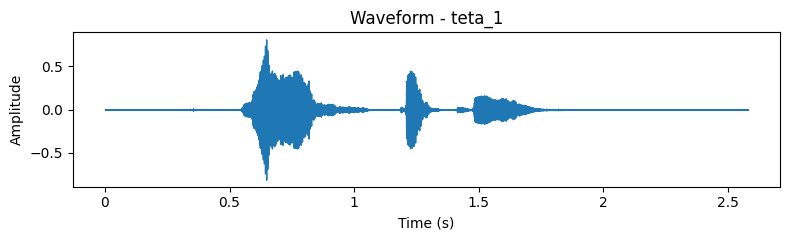

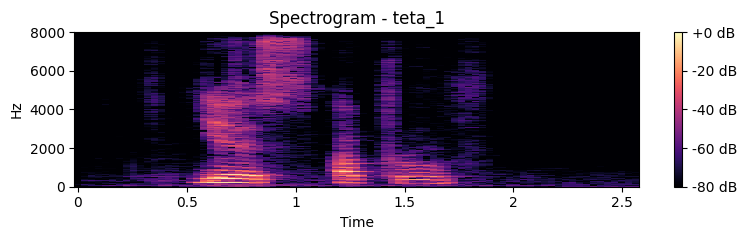

/content/audio_utils.py:20: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(path, sr=sr, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


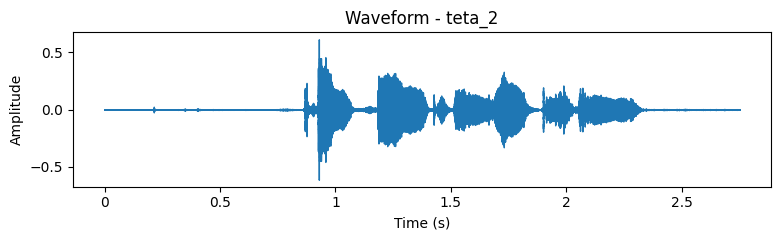

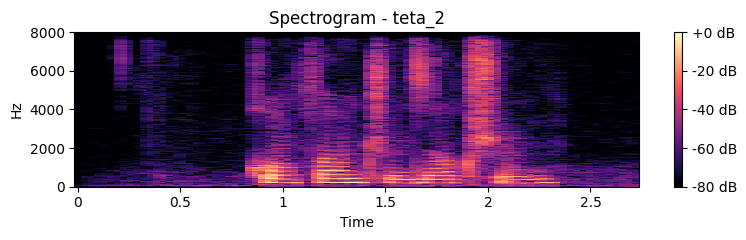

/content/audio_utils.py:20: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(path, sr=sr, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


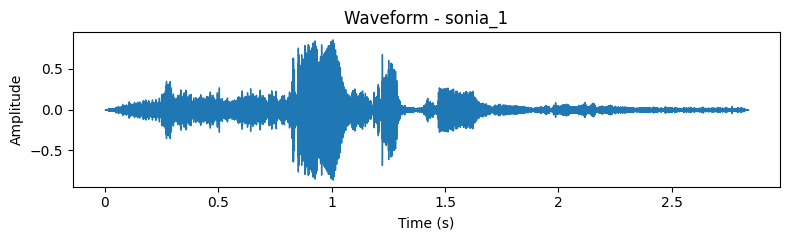

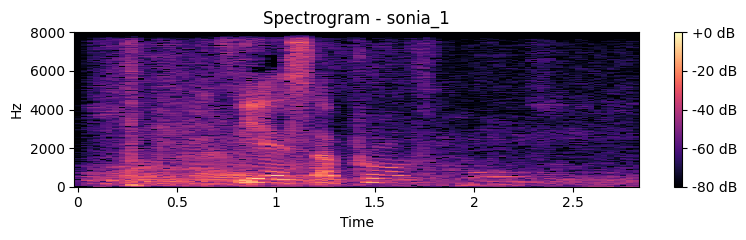

/content/audio_utils.py:20: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(path, sr=sr, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


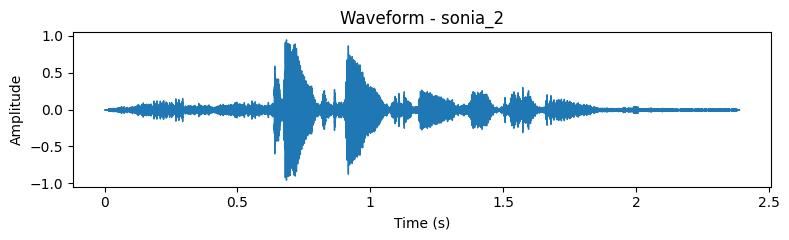

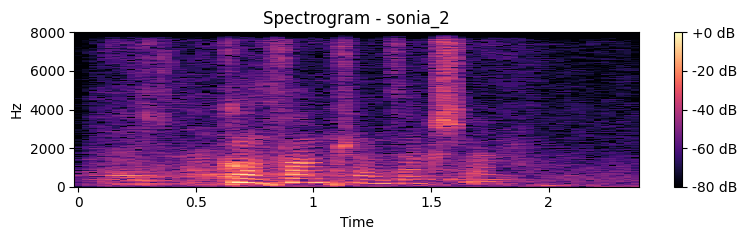

/content/audio_utils.py:20: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(path, sr=sr, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


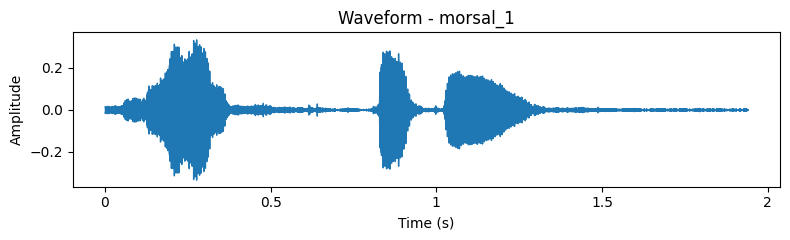

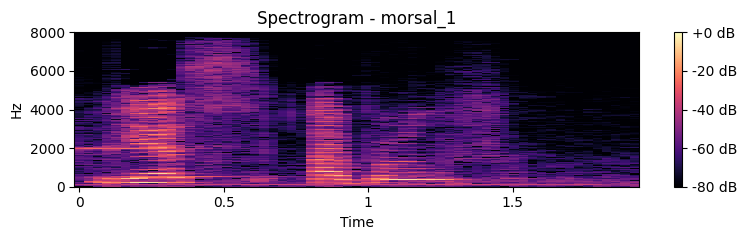

/content/audio_utils.py:20: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(path, sr=sr, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


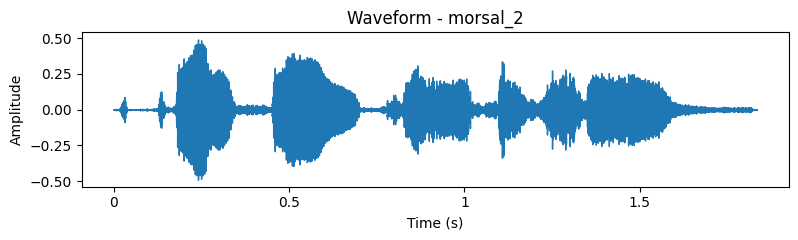

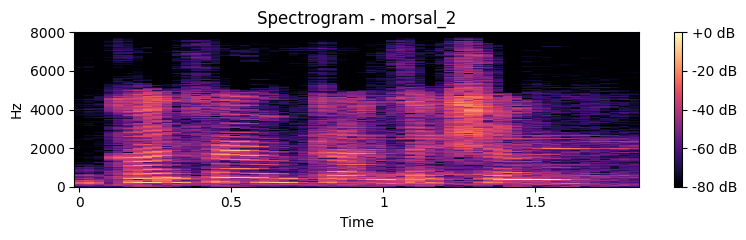

/content/audio_utils.py:20: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(path, sr=sr, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


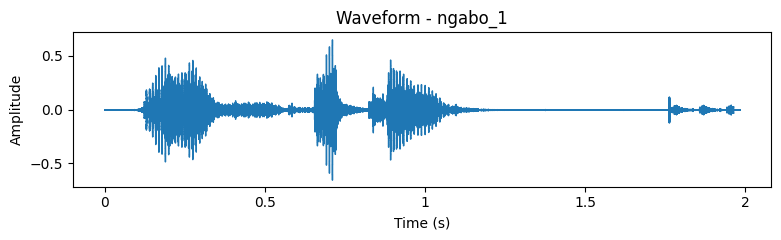

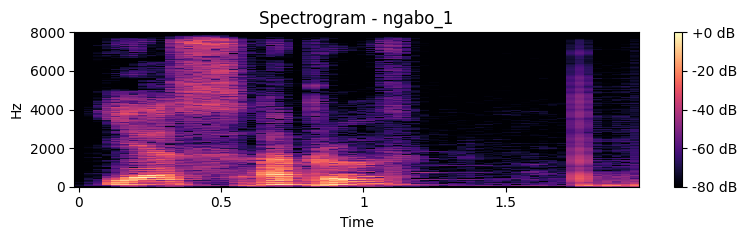

/content/audio_utils.py:20: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(path, sr=sr, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


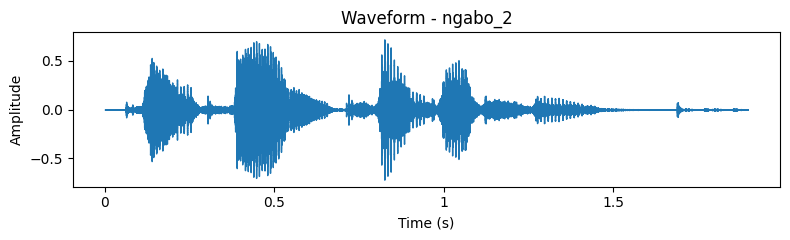

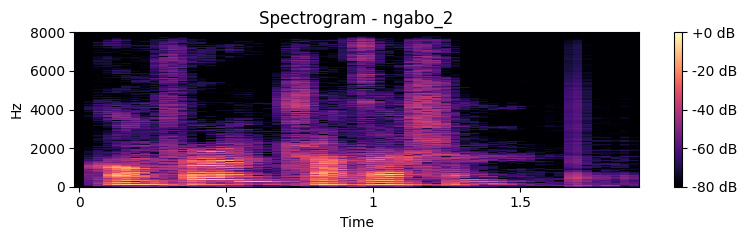

In [10]:
for member in members:
    for s in samples:
        path = f"{RAW_DIR}/{member}_{s}.m4a"
        y, sr = load_audio(path)
        label = f"{member}_{s}"
        plot_waveform(y, sr, label, save_path=f"{CLEAN_DIR}/waveforms/{label}.png")
        plot_spectrogram(y, sr, label, save_path=f"{CLEAN_DIR}/spectrograms/{label}.png")

## 3. Augmentations
Two augmentations per sample, as asked: pitch shift and time stretch. Added a background-noise
version too since it's the kind of noise our "unauthorized attempt" simulation will need later.
Augmented files are saved as wav so the feature extraction step reads consistent, uncompressed audio.

In [11]:
augmented_records = []  # (member, sample_id, aug_name, y)

for member in members:
    for s in samples:
        path = f"{RAW_DIR}/{member}_{s}.m4a"
        y, sr = load_audio(path)
        sample_id = f"{member}_{s}"

        # original (clean, resampled) version
        save_wav(y, sr, f"{CLEAN_DIR}/augmented/{sample_id}_original.wav")
        augmented_records.append((member, sample_id, "original", y))

        # augmentation 1: pitch shift
        y_pitch = augment_pitch_shift(y, sr, n_steps=4)
        save_wav(y_pitch, sr, f"{CLEAN_DIR}/augmented/{sample_id}_pitch.wav")
        augmented_records.append((member, sample_id, "pitch_shift", y_pitch))

        # augmentation 2: time stretch
        y_stretch = augment_time_stretch(y, rate=0.85)
        save_wav(y_stretch, sr, f"{CLEAN_DIR}/augmented/{sample_id}_stretch.wav")
        augmented_records.append((member, sample_id, "time_stretch", y_stretch))

        # augmentation 3 (bonus): background noise
        y_noise = augment_add_noise(y, noise_factor=0.005)
        save_wav(y_noise, sr, f"{CLEAN_DIR}/augmented/{sample_id}_noise.wav")
        augmented_records.append((member, sample_id, "background_noise", y_noise))

print(f"Generated {len(augmented_records)} audio versions (original + 3 augmentations x 8 samples)")

/content/audio_utils.py:20: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(path, sr=sr, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/content/audio_utils.py:20: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(path, sr=sr, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/content/audio_utils.py:20: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(path, sr=sr, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:1

Generated 32 audio versions (original + 3 augmentations x 8 samples)


/content/audio_utils.py:20: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(path, sr=sr, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Quick visual check that the augmentations actually changed something, using one sample as an example.

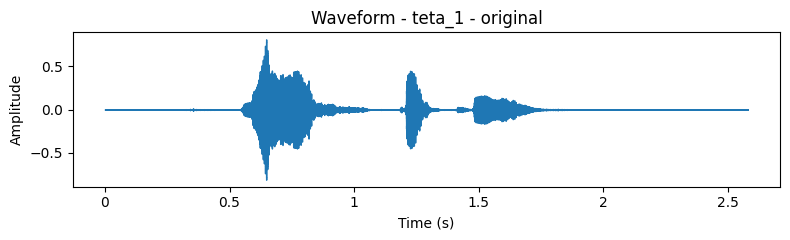

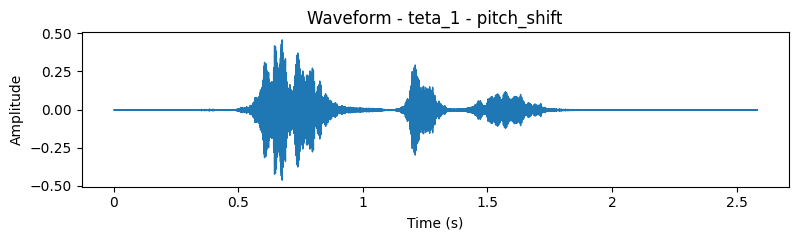

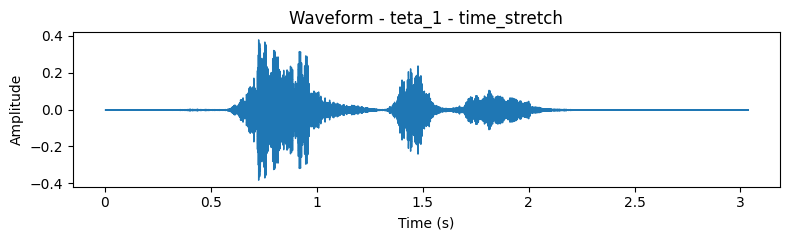

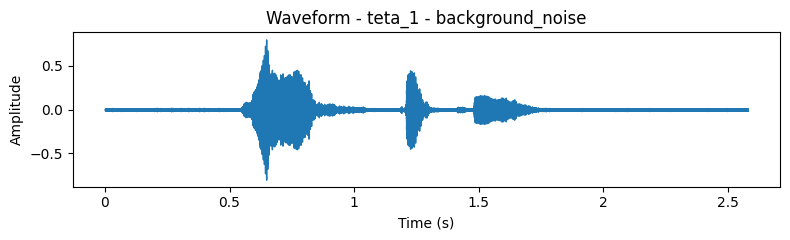

In [12]:
example = [r for r in augmented_records if r[1] == "teta_1"]
for member, sample_id, aug_name, y in example:
    plot_waveform(y, SAMPLE_RATE, f"{sample_id} - {aug_name}")

## 4. Feature extraction
For every version (original + augmented) we pull MFCCs (13 coefficients, averaged over time),
spectral roll-off and energy, then save everything to `audio_features.csv`.

In [13]:
rows = []
for member, sample_id, aug_name, y in augmented_records:
    feats = extract_features(y, SAMPLE_RATE)
    feats["member"] = member
    feats["sample_id"] = sample_id
    feats["augmentation"] = aug_name
    rows.append(feats)

features_df = pd.DataFrame(rows)

# reorder so the id columns come first
id_cols = ["member", "sample_id", "augmentation"]
features_df = features_df[id_cols + [c for c in features_df.columns if c not in id_cols]]

os.makedirs(os.path.dirname(FEATURES_CSV), exist_ok=True)
features_df.to_csv(FEATURES_CSV, index=False)

print(f"Saved {len(features_df)} rows to {FEATURES_CSV}")
features_df.head()

Saved 32 rows to /content/data/cleaned/audio_features.csv


,member,sample_id,augmentation,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,spectral_rolloff,energy
0,teta,teta_1,original,-415.476074,65.436806,26.792204,4.642013,-9.983325,0.440194,-12.324099,-1.705827,-6.823023,-2.701324,3.289757,-0.722706,0.215961,4229.359568,0.004375
1,teta,teta_1,pitch_shift,-446.873505,75.551651,20.754858,-10.743688,-10.725444,-6.678803,-10.430420,0.058916,-6.569387,6.343645,-6.067224,0.569928,-3.974183,4336.612654,0.001876
2,teta,teta_1,time_stretch,-442.725250,66.865593,26.422083,5.112366,-11.899199,0.133493,-13.742114,-2.002850,-8.054574,-3.671087,2.586427,-2.100805,-1.310448,4236.513158,0.001781
3,teta,teta_1,background_noise,-262.075800,21.734002,11.190351,0.655115,-6.974023,-5.769952,-6.926263,-4.498943,-5.820436,-3.639581,0.229055,-1.802380,-0.624629,6009.837963,0.004403
4,teta,teta_2,original,-371.732117,92.969063,21.408190,-3.261211,-10.708775,-2.853484,-8.779115,2.450653,-8.469780,-3.158761,-4.447468,-0.744949,-5.318542,3751.726017,0.002891


## 5. Sanity check
Makes sense that `original` energy differs a bit from the noise-augmented version, and MFCC_1 (loudness-related) stays roughly in the same range per member.

In [14]:
features_df.groupby("augmentation")[["energy", "spectral_rolloff"]].mean()

,energy,spectral_rolloff
augmentation,,
background_noise,0.006537,5165.278276
original,0.006512,3478.253443
pitch_shift,0.002999,3753.986597
time_stretch,0.003137,3513.571917


In [16]:
import shutil
shutil.make_archive("/content/task3_outputs", "zip", "/content/data/cleaned")

'/content/task3_outputs.zip'